<a class="anchor" id="1-bullet"></a>
# Новая лента: проверка боем

Команда разработчиков рекомендательных систем развлекательного приложения с функцией «бесконечной» ленты создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Меня, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Цели и задачи проекта
Рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

## Содержимое проекта

 [1. Работа с историческими данными](#metka_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.1. Загрузка исторических данных](#metka_1_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.2. Знакомство с данными](#metka_1_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.3. Анализ числа регистраций](#metka_1_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.4. Анализ числа просмотренных страниц](#metka_1_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.5. Доля пользователей, просмотревших более четырёх страниц](#metka_1_5)\
 [2. Подготовка к тесту](#metka_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.1. Расчёт размера выборки](#metka_2_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.2. Расчёт длительности A/B-теста](#metka_2_2)\
 [3. Мониторинг А/В-теста](#metka_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.1. Проверка распределения пользователей](#metka_3_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.2. Проверка пересечений пользователей](#metka_3_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.3. Равномерность разделения пользователей по устройствам](#metka_3_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.4. Равномерность распределения пользователей по регионам](#metka_3_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.5. Вывод после проверки A/B-теста](#metka_3_5)\
 [4. Проверка результатов A/B-теста](#metka_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.1. Получение результатов теста и подсчёт основной метрики](#metka_4_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик](#metka_4_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.3. Сравнение доли успешных первых сессий](#metka_4_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.4. Насколько статистически значимо изменение ключевой метрики](#metka_4_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.5. Вывод по результатам A/B-эксперимента](#metka_4_5)\

---

<a id='metka_1'></a>
### 1. Работа с историческими данными

<a id='metka_1_1'></a>
#### 1.1. Загрузка исторических данных

In [1]:
#Импортирую все необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

from math import ceil #округляет в большую сторону

In [2]:
sessions_history = pd.read_csv('https://...sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


<a id='metka_1_2'></a>
#### 1.2. Знакомство с данными

In [3]:
#1.Делаю группировку по идентификаторам пользователей,
#2.Считаю количество уникальных сессий для этой группировки,
#3.Сортирую их по убыванию от большего к меньшему 
#4.В рассмотрение беру первого пользователя с максимальным числом уникальных сессий,
#5.Вывожу данные по пользователю с таким id
max_id = sessions_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False).index[0]
sessions_history[sessions_history['user_id'] == max_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


<a id='metka_1_3'></a>
#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, проанализируем количество зарегистрированных активных пользователей за каждый день без накопления.

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.
- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


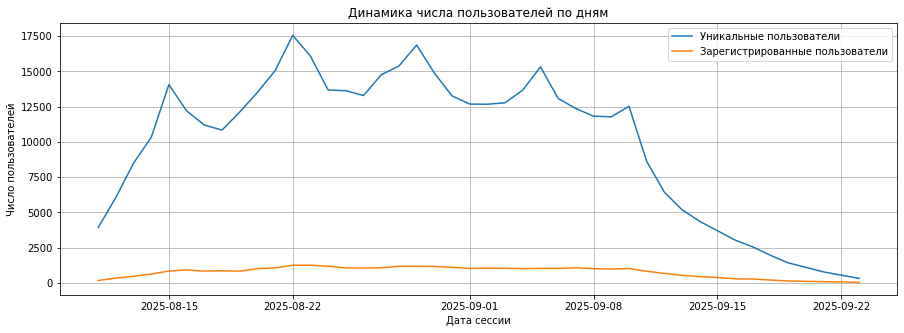

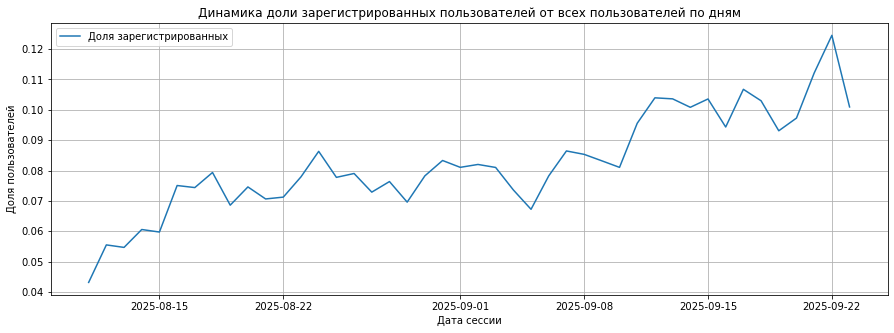

In [4]:
#Проверяю тип данных
sessions_history.info()

#Привожу дату сессии к формату datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

#Агрегирую исторические данные для каждого дня наблюдения в отдельный датафрейм
df = sessions_history.groupby('session_date').agg({'user_id': 'nunique',          #количество уникальных пользователей в день
                                                   'registration_flag': 'sum'})   #количество зарегистрир. пользователей в день

#В созданный датафрейм добавляю столбец с рассчитанной долей зарегистрированных пользователей от всех пользователей по дням
df['dolya'] = df['registration_flag'] / df['user_id']

#Строю линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['user_id'], label='Уникальные пользователи')
plt.plot(df.index, df['registration_flag'], label='Зарегистрированные пользователи')

plt.title('Динамика числа пользователей по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Число пользователей')
plt.grid(True)
plt.legend()
plt.show()

#Строю отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['dolya'], label='Доля зарегистрированных')

plt.title('Динамика доли зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля пользователей')
plt.grid(True)
plt.legend()
plt.show()

- В рассматриваемый период наблюдалось сначала увеличение, а затем резкое снижение числа уникальных пользователей к концу периода, при этом количество зарегистрированных пользователей оставалось относительно стабильным на низком уровне. Доля же зарегистрированных пользователей колебалась в диапазоне 0,04–0,12, достигнув пика ближе к концу периода, и её рост — это следствие уменьшения общего числа пользователей, а не увеличения числа регистраций.

<a id='metka_1_4'></a>
#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

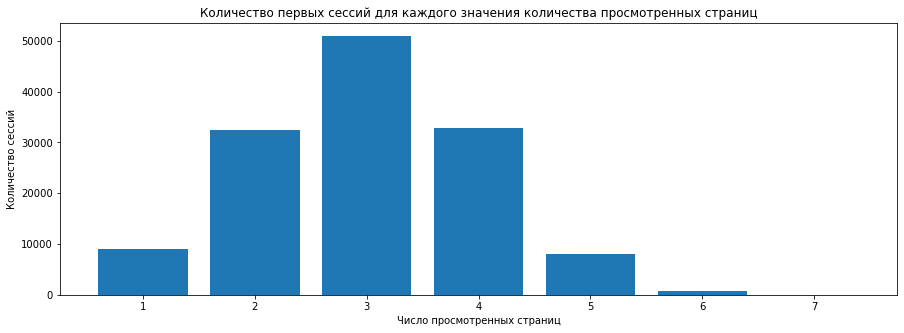

In [5]:
#1.Отфильтровываю только первые сессии,
#2.Среди этих сессий провожу группировку по каждому значению количества просмотренных страниц
#3.Считаю количество таких сессий (использую сумму, так как первые сессии имеют значение 1)
df2 = sessions_history[sessions_history['session_number'] == 1].groupby('page_counter')['session_number'].sum()

#Строю столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий
plt.figure(figsize=(15, 5))
plt.bar(df2.index, df2.values)
plt.title('Количество первых сессий для каждого значения количества просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

- Большинство первых сессий характеризуется просмотром 3 страниц (около 50 000 сессий), далее количество сессий резко снижается с увеличением числа просмотренных страниц, поэтому можно счесть успехом если пользователь просмотрел 4 и более страниц.

<a id='metka_1_5'></a>
#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

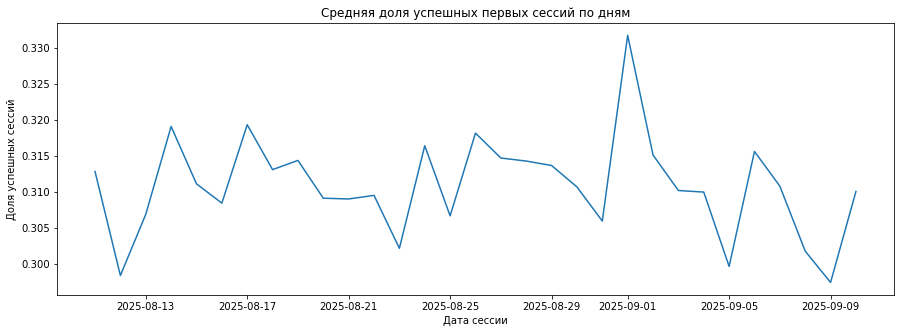

In [6]:
#Создаю новый столбец, где все значения изначально нулевые
sessions_history['good_session'] = 0

#1.Отбираю те сессии, где количество просмотренных страниц 4 и более
#2.Заменяю 0 на 1 в новом столбце, где выполняется условие о просмотре более 3 страниц 
sessions_history.loc[sessions_history['page_counter'] >= 4, 'good_session'] = 1

#Определяю среднее значение (долю) успешных первых сессий от всех первых сессий пользователей, для этого:
#1.Отфильтровываю только первые сессии,
#2.Среди этих сессий провожу группировку по каждой дате,
#3.Считаю долю успешных сессий (среднее по 'good_session')
df3 = sessions_history[sessions_history['session_number'] == 1].groupby('session_date')['good_session'].mean()

#Строю график со средним значением доли успешных первых сессий от всех первых сессий пользователей
plt.figure(figsize=(15, 5))
plt.plot(df3.index, df3.values)
plt.title('Средняя доля успешных первых сессий по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля успешных сессий')
plt.show()

- Средняя доля успешных первых сессий (где пользователи просмотрели более 3 страниц) колеблется в диапазоне 0,30–0,33 с небольшими всплесками и спадами, достигая максимального значения в первых числах сентября.

<a id='metka_2'></a>
### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

<a id='metka_2_1'></a>
#### 2.1. Расчёт размера выборки

In [7]:
# Задайте параметры:
alpha = 0.05     # Уровень значимости
beta = 0.2       # Ошибка второго рода, часто 1 - мощность
power = 1 - beta # Мощность теста
p = 0.3          # Базовый уровень доли
mde = 0.03 * p   # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


<a id='metka_2_2'></a>
#### 2.2. Расчёт длительности A/B-теста

In [8]:
# Среднее количество пользователей приложения в день по историческим данным
#1.Группирую по дате сессии,
#2.Считаю уникальных пользователей в эти дни,
#3.Вычисляю среднее количества этих пользователей за все дни
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2 * sample_size / avg_daily_users) #умножаю на 2, потому что sample_size - размер выборки для КАЖДОЙ группы

print(f"Длительность A/B-теста при уровне трафика в {ceil(avg_daily_users)} пользователей/день составит {test_duration} дней.")

Длительность A/B-теста при уровне трафика в 9908 пользователей/день составит 9 дней.


<a id='metka_3'></a>
### 3. Мониторинг А/В-теста

<a id='metka_3_1'></a>
#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а метрики корректно считаются.

- Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем процентную разницу в количестве пользователей в группах A и B. Визуализируем возможное различие двух групп.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

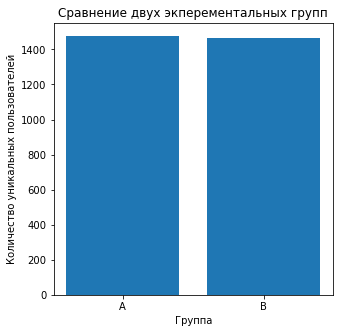

Разница в количестве пользователей в группах A и B 0.74%


In [9]:
sessions_test_part = pd.read_csv('https://...sessions_project_test_part.csv')

sessions_test_part['test_group'].unique() #в эксперименте 2 группы - А и В

#Отбираю пользователей (строки датафрейма) по по экспериментальным группам для одного дня наблюдения
a = sessions_test_part[sessions_test_part['test_group'] == 'A']
b = sessions_test_part[sessions_test_part['test_group'] == 'B']

#Рассчитываю количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения
un_a_count = a['user_id'].nunique() #1477
un_b_count = b['user_id'].nunique() #1466

#Строю столбчатую диаграмму, где по оси X будут эксперементальные группы, по оси Y — количество их уникальных пользователей
plt.figure(figsize=(5, 5))
plt.bar(['A', 'B'], [un_a_count, un_b_count])
plt.title('Сравнение двух экперементальных групп')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')
plt.show()

#Вывожу процентную разницу в количестве пользователей в группах A и B
print(f'Разница в количестве пользователей в группах A и B {round(100 * abs(un_a_count-un_b_count) / un_a_count, 2)}%')

<a id='metka_3_2'></a>
#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [10]:
#Проверяю пуст ли список пересечений
if list(set(a['user_id']) & set(b['user_id'])):
    print(list(set(a['user_id']) & set(b['user_id']))) # список пользователей, которые есть в обеих группах
else:
    print("Пользователей, которые встречаются одновременно в группах A и B не существует")

Пользователей, которые встречаются одновременно в группах A и B не существует


<a id='metka_3_3'></a>
#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

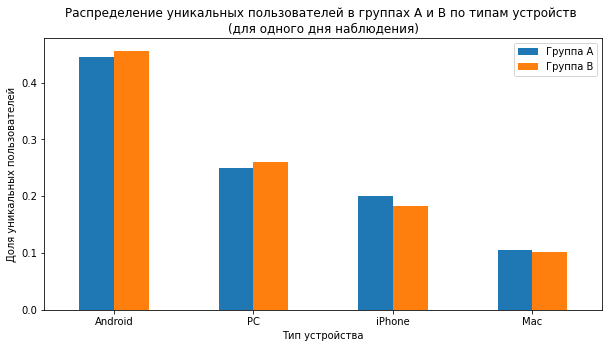

In [11]:
#1.Удаляю дубликаты по каждому user_id и device, чтобы оставить по 1 записи на пользователя (drop_duplicates)
#2.Подсчитываю, сколько раз встречается каждый тип устройства (value_counts)
#3.Определяю доли каждого типа устройства для уникальных пользователей групп (normalize)
device_a = a.drop_duplicates(subset=['user_id', 'device'])['device'].value_counts(normalize=True)
device_b = b.drop_duplicates(subset=['user_id', 'device'])['device'].value_counts(normalize=True)

#Создаю датафрейм, чтоб разместить на одном графике две группы
df4 = pd.DataFrame({'Группа A': device_a,
                    'Группа B': device_b})

#Строю столбчатые диаграммы, где по оси X будут типы устройств эксперементальных групп, по оси Y — доля уникальных пользователей
df4.plot(kind='bar', figsize=(10, 5))
plt.title('Распределение уникальных пользователей в группах A и B по типам устройств \n(для одного дня наблюдения)')
plt.xlabel('Тип устройства')
plt.ylabel('Доля уникальных пользователей')
plt.xticks(rotation=0)
plt.show()

<a id='metka_3_4'></a>
#### 3.4. Равномерность распределения пользователей по регионам

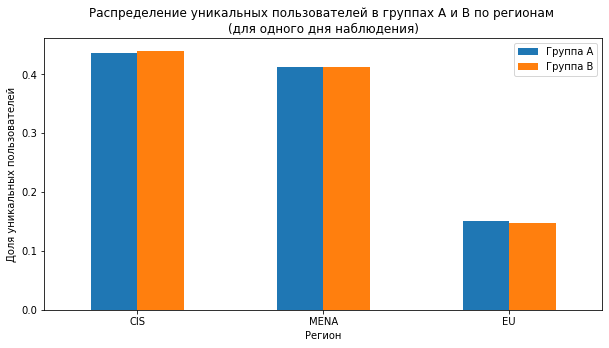

In [12]:
#1.Удаляю дубликаты по каждому user_id и region, чтобы оставить по 1 записи на пользователя (drop_duplicates)
#2.Подсчитываю, сколько раз встречается каждый регион (value_counts)
#3.Определяю доли каждого региона для уникальных пользователей групп (normalize)
region_a = a.drop_duplicates(subset=['user_id', 'region'])['region'].value_counts(normalize=True)
region_b = b.drop_duplicates(subset=['user_id', 'region'])['region'].value_counts(normalize=True)

#Создаю датафрейм, чтоб разместить на одном графике две группы
df5 = pd.DataFrame({'Группа A': region_a,
                    'Группа B': region_b})

#Строю столбчатые диаграммы, где по оси X будут регионы эксперементальных групп, по оси Y — доля уникальных пользователей
df5.plot(kind='bar', figsize=(10, 5))
plt.title('Распределение уникальных пользователей в группах A и B по регионам \n(для одного дня наблюдения)')
plt.xlabel('Регион')
plt.ylabel('Доля уникальных пользователей')
plt.xticks(rotation=0)
plt.show()

<a id='metka_3_5'></a>
#### 3.5. Вывод после проверки A/B-теста


- Процентная разница в количестве пользователей между группами А и В составляет менее 1%, что является статистически незначимым отклонением. Такой дисбаланс не влияет на достоверность результатов теста и им можно пренебречь. Тем не менее стоило проверить, возможно, дело в пользователях, которые могли попасть в обе группы.
- Независимость выборок А/В-теста соблюдена. Пересечение пользователей между тестовой и контрольной группами не обнаружено. Это гарантирует, что результаты не искажены «двойным подсчётом» действий одних и тех же пользователей.
- Равномерность распределения по категориальным переменным сохраняется:
    - по устройствам распределение сбалансировано — в обеих группах доминирует Android, доля Mac незначительна и сопоставима. Это исключает искажение результатов из-за различий в поведении пользователей на разных устройствах.
    - по регионам наблюдается равномерное распределение с доминированием двух основных регионов — Содружества Независимых Государств и Ближнего Востока с Северной Африкой. Перекоса в пользу одной из групп нет, что подтверждает репрезентативность выборок.

Заключение:
- все критические показатели (размер выборок, их независимость, равномерность распределения по ключевым категориям) соответствуют требованиям корректного А/В-теста. Это позволяет с уверенностью интерпретировать будущие результаты сравнения групп А и В как достоверные и репрезентативные. И на основании проведённого анализа А/В-теста можно сделать вывод, что эксперимент проходит корректно, без существенных нарушений методологии.

<a id='metka_4'></a>
### 4. Проверка результатов A/B-теста

<a id='metka_4_1'></a>
#### 4.1. Получение результатов теста и подсчёт основной метрики

- Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [13]:
sessions_test = pd.read_csv('https://...sessions_project_test.csv')

#Создаю новый столбец, где все значения изначально нулевые
sessions_test['good_session'] = 0

#1.Отбираю те сессии, где количество просмотренных страниц 4 и более
#2.Заменяю 0 на 1 в новом столбце, где выполняется условие о просмотре более 3 страниц 
sessions_test.loc[sessions_test['page_counter'] >= 4, 'good_session'] = 1

#Вывожу первые 7 строк датафрейма для проверки нового столбца
sessions_test.head(7)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
5,31F7A42B32103403,E9B64B779C3348ED,2025-10-20,2025-10-20 17:09:41,2025-10-19,2,0,2,CIS,PC,B,0
6,87C09E3E3B334959,FECFF83C13DC9364,2025-10-22,2025-10-22 23:51:42,2025-10-20,3,0,4,CIS,iPhone,B,1


<a id='metka_4_2'></a>
#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

- Нулевая гипотеза (Н0): "Доли успешных первых сессий между группами значимо не различаются (H0: p_a = p_b)".<br><br>

- Альтернативная гипотеза (H1): "Доля успешных первых сессий ниже в группе А по сравнению с группой B (H1: p_a < p_b)".<br><br>
        
- Прокси-метрика помогает убедиться, что изменения не ломают базовую логику приложения: "Первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций".<br><br>
    
- Примеры барьерных метрик, сигнализирующих о критическом ухудшении пользовательского опыта:

    - общая доля сессий (отслеживаем, не упала ли общая активность пользователей) - новый алгоритм не должен «отпугивать» пользователей, снижая базовую вовлечённость.<br>
    - количество просмотренных страниц в целом, а не только «успешные» сессии (проверяем, не снизилось ли общее потребление контента).<br>
    - доля «коротких» сессий - рост таких сессий сигнализирует о том, что пользователи не находят интересный контент сразу.

<a id='metka_4_3'></a>
#### 4.3. Сравнение доли успешных первых сессий

In [14]:
#Отбираю первые сессии (строки датафрейма) по экспериментальным группам за весь период наблюдения
A = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]
B = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]

#Считаю долю успешных первых сессий по экспериментальным группам за весь период наблюдения
p_A = A['good_session'].mean()
p_B = B['good_session'].mean()

print(f'Разница долей успешных первых сессий для выборок А и В = {p_B - p_A:.3f}, т.е. {100*(p_B - p_A):.1f}%')
if (p_B - p_A) < 0:
    print(f'Знак «–» говорит об ухудшении метрики в группе B, но итоговый вывод зависит от статистической проверки...')
else:
    print(f'Знак «+» говорит об улудшении метрики в группе B, но итоговый вывод зависит от статистической проверки...')

Разница долей успешных первых сессий для выборок А и В = -0.001, т.е. -0.1%
Знак «–» говорит об ухудшении метрики в группе B, но итоговый вывод зависит от статистической проверки...


<a id='metka_4_4'></a>
#### 4.4. Насколько статистически значимо изменение ключевой метрики

Мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

In [15]:
# Подсчёт числа успешных и общих сессий для каждой группы
m_A = A['good_session'].sum()  # число успешных первых сессий в группе А
n_A = A.shape[0]               # общее число первых сессий в группе A

m_B = B['good_session'].sum()  # число успешных первых сессий в группе B
n_B = B.shape[0]               # общее число первых сессий в группе B

#Проверяю предпосылку о достаточном количестве данных
if (p_A*n_A>10) and ((1-p_A)*n_A>10) and (p_B*n_B>10) and ((1-p_B)*n_B> 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

#Провожу Z-теста пропорций
stat, p_value = proportions_ztest([m_A, m_B], [n_A, n_B], alternative='smaller') # т.к. H1: p_a < p_b

#Вывожу полученное p-value 
print(f'pvalue={p_value}')

if p_value > alpha:
    print('Нулевая гипотеза находит подтверждение! Различия не являются статистически значимыми.')
else:
    print('Нулевая гипотеза не находит подтверждения! Различия статистически значимы. Изменение в группе B повлияло на метрику')

#Интерпретация
print(f'''\nПри переходе к новому алгоритму, который (по мнению команды разработчиков рекомендательных систем)
будет показывать более интересный контент, статистически значимых различий в доле успешных первых
сессий между группами A и B не обнаружено.''')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.5783523649187868
Нулевая гипотеза находит подтверждение! Различия не являются статистически значимыми.

При переходе к новому алгоритму, который (по мнению команды разработчиков рекомендательных систем)
будет показывать более интересный контент, статистически значимых различий в доле успешных первых
сессий между группами A и B не обнаружено.


<a id='metka_4_5'></a>
#### 4.5. Вывод по результатам A/B-эксперимента

- Необходимый размер выборки для каждой гуппы - 41040 задействованных пользователей и длительность A/B-теста при уровне трафика в 9908 пользователей в день составит 9 дней.<br><br>

- При переходе к новому алгоритму, который (по мнению команды разработчиков рекомендательных систем) будет показывать более интересный контент, статистически значимых различий в доле успешных первых сессий между группами A и B не обнаружено.<br><br>

- pvalue=0.58 что больше alpha=0.05, поэтому нулевая гипотеза находит подтверждение "Доли успешных первых сессий между группами значимо не различаются (H0: p_a = p_b)".<br><br>

- Нововведение в приложение внедрять не стоит!

[В начало](#1-bullet)